mix them pixels yooo

In [1]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import isnan
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from scipy.optimize import curve_fit
import randomforest_CHAIN_S2 as rfcc

In [2]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

In [3]:

# Plotting settings and functions

plt.rcParams['font.family'] = 'serif' #sans-serif'

def plot_multi_result(x_array, 
                      y_array, 
                      alpha, 
                      colour,
                      metric, 
                      cmap, 
                      fig_title, 
                      x_axis_label, 
                      y_axis_label, 
                      stats_values, 
                      line_1_1, 
                      sensor_code, 
                      class_code,
                      type = "scatter",
                      h_lines = None, 
                      save = False, 
                      output_dir = None,
                      output_name = None, 
                      figsize = 3):
    fig, ax = plt.subplots(x_array.shape[1]//2 + x_array.shape[1]%2, 2, figsize = (10, (x_array.shape[1]//2 + x_array.shape[1]%2)*figsize), sharex = True, sharey = True)
    fig.tight_layout(pad = 3)
    if isinstance(y_array, pd.DataFrame):
        y_array = y_array.values
    if isinstance(stats_values, pd.DataFrame):
        stats_values = stats_values.values
    

    for col in range(x_array.shape[1]):
        col_name = x_array.columns[col]
        if isinstance(colour, dict):
            class_colour = colour.get(col_name, "magenta")
        else:
            class_colour = colour
        if type == "scatter":
            ax[col//2, col%2].scatter(x_array[col_name], y_array[:,col], alpha = alpha, c = class_colour, cmap = cmap)
        elif type == "hexbin":
            hb = ax[col//2, col%2].hexbin(x = x_array[col_name], 
                                     y = y_array[:, col], 
                                     gridsize = 50, 
                                     bins = "log", 
                                     cmap = cmap)
            
            fig.colorbar(hb, ax=ax[col//2, col%2], label='counts')

        ax[col//2, col%2].set_xlabel(f"{x_axis_label} of {col_name.replace("_", " ")}")
        ax[col//2, col%2].set_ylabel (y_axis_label)
        if stats_values is not None:
            ax[col//2, col%2].annotate(f"{metric} = {stats_values[metric][col]:.3f}", xy = (0.05, 0.8), xycoords = "axes fraction")
        if line_1_1:
            ax[col//2, col%2].axline((0,0), slope = 1, color = "lightgrey", linestyle = "--")
        if h_lines is not None:
            for h in h_lines:
                ax[col//2, col%2].axhline(y = h[0], color = h[1], linestyle = ":")
    if x_array.shape[1] % 2 == 1:
        ax[-1, -1].set_visible(False)  
    fig.suptitle(fig_title, y = 1)
    
    if save: 
        if not sensor_code or not class_code:
            ValueError("Sensor code and class code must be provided to save the figure.")
        if output_dir is None :
            output_dir = "./"
        
        os.makedirs(output_dir, exist_ok=True)
        filename = f"{sensor_code}_{class_code}_{output_name}.svg"
        filepath = os.path.join(output_dir, filename)
        fig.savefig(filepath, bbox_inches = "tight")
    plt.show()

def calc_eval_stats(true_values, predicted, include_zeros = False):
    r2_list = []
    mse_list = []
    rmse_list = []
    mae_list = []
    mape_list = []
    all_stats = {}
    predicted = pd.DataFrame(predicted)
    true_values = pd.DataFrame(true_values)
    
    for i in range(true_values.shape[1]):

        x = true_values.iloc[:, i]
        y = predicted.iloc[:, i]
        if not include_zeros:
            x = x[x != 0]
            y = y.loc[x.index]
        r2 = r2_score(x, y)
        mse = mean_squared_error(x, y)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(x, y)
       
        den = x.replace(0, np.nan)

        mape = np.nanmean(np.abs(x - y) / den * 100)

        
        
        # try: 
        #     mape = np.abs(true_values.iloc[:, i] - predicted[:, i]) / true_values.iloc[:, i]*100
        # except ZeroDivisionError:
        #     mape = np.nan
        # clean_mape = [x for x in mape if not isnan(x)]
        # mape = np.mean(clean_mape)
        
        
        r2_list.append(r2)
        mse_list.append(mse)
        rmse_list.append(rmse)
        mae_list.append(mae)
        mape_list.append(mape)
        
    all_stats["R2"] = r2_list
    all_stats["MSE"] = mse_list
    all_stats["RMSE"] = rmse_list
    all_stats['MAE'] = mae_list
    all_stats['MAPE'] = mape_list
    
    return all_stats

def sigmoid(x, L ,x0, k, b):
    y = L / (1 + np.exp(-k*(x-x0))) + b
    return (y)

def fit_best_curve(x, y, criterion = ("R2", "max"), include_zeros = True):
     
    """Fit a set of lines to the data and decide on the best one based on R squared value.
        
    Args
        x (array-like): Independent variable data.
        y (array-like): Dependent variable data.
        criterion (str, str): Tuple of the criterion to evaluate the best fit on and how to choose best fit (min or max criterion value). Default is "R2". Options are MAE, RMSE, MSE, MAPE, R2.
        
    Output
        best_fit_params (tuple): Parameters of the best fit curve.
        all_curve_params (dict): Parameters of all fitted curves.
        best_fit_line (str) : Type of curve that fits best
        all_stats (dict) : Evaluation stats of the fitted curves.
    """
    
    all_curve_params = {}
    crit_ordering = criterion[1]
    criterion = criterion[0]
    
    
    # Fit sigmoid curve    
    p0 = [max(y), np.mean(x), 1, 0] # mandatory initial guess
    popt, _ = curve_fit(sigmoid, x, y, p0, method='trf')
    y_pred_sigmoid = sigmoid(x, *popt)
    all_curve_params = {'sigmoid': popt}

    sigmoid_stats = calc_eval_stats(y, y_pred_sigmoid, include_zeros= True)
    all_stats = {'sigmoid' : sigmoid_stats}
    
    # Fit straight line
    b, m = np.polyfit(x, y, 1)
    all_curve_params["linear"] = (b, m)
    y_pred_linear = b*x +m

    linear_stats = calc_eval_stats(y, y_pred_linear, include_zeros = include_zeros)
    all_stats['linear'] = linear_stats
    
    # Pick best curve
    sigmoid_crit = sigmoid_stats[criterion][0]
    linear_crit = linear_stats[criterion][0]
    d = {"sigmoid": sigmoid_crit, "linear" : linear_crit}
    if crit_ordering == "max":
        best_fit_line = max(d, key = d.get)
    elif crit_ordering == "min":
        best_fit_line = min(d, key = d.get)
    else:
        ValueError("Criterion ordering must be either 'max' or 'min'")
    best_fit_params = all_curve_params.get(best_fit_line)
    
    return best_fit_params, all_curve_params, best_fit_line, all_stats

def invert_predicted_values(predicted_values, y_test, fitted_curves):
    """ 
    Invert the best fitted curves to back-calculate the expected/adjusted FPC values for any given regression output.
    
    """
    predicted_covers = pd.DataFrame(index = y_test.index, columns = y_test.columns)
    for col in range(y_test.shape[1]-1):
        class_name = y_test.columns[col]
        
        if len(fitted_curves[class_name]) == 4:
            # Access sigmoid params
            L, x0, k, b = fitted_curves[class_name]
            # values = np.array([x if x > b else b for x in predicted_values[:,col] ])
            # Calculate inverse sigmoid for predicted values
            x_result = inverse_sigmoid(predicted_values[:, col], L, x0, k, b)
            x_result = np.clip(x_result, 0, 1)
            
            # Store new predicted values
            predicted_covers[class_name] = x_result
            
        elif len(fitted_curves[class_name]) == 2:
            # Access linear params
            b, m = fitted_curves[class_name]
            # Calculate inverse linear for predicted values
            x_result = (predicted_values[:, col] - m) / b
            x_result = np.clip(x_result, 0, 1)
            
            # Store new predicted values
            predicted_covers[class_name] = x_result
            
    return predicted_covers

def inverse_sigmoid(y, L, x0, k, b):
    """
    Inverse of sigmoid function.
    Given y, returns x.
    """
    
    y = np.asarray(y, dtype=float)

    # Check if y is in valid range
    if np.any((y - b) <= 0) or np.any((y - b) >= L):
        print("Warning: y values outside valid range (b < y < L+b)")
        
    bad = (y - b <= 0) | (y - b >= L)
    if np.any(bad):
        print("Adjusting bad y values:", y[bad])
        
    # Small epsilon to avoid log(0) or negative arguments
    eps = 1e-12

    # Compute the valid range for y
    y_min = b + eps
    y_max = L + b - eps

    # Clip y to the range
    y = np.clip(y, y_min, y_max)
        
    x = x0 - (1/k) * np.log(L/(y - b) - 1)

    return x

def combine_class_regression(classification_results = pd.DataFrame, regression_results = pd.DataFrame, threshold = float):
    overall_results = pd.DataFrame(index = classification_results.index, columns= classification_results.columns)
    for col in regression_results.columns:
        for row in regression_results.index:
            if classification_results.loc[row, col] > threshold:
                overall_results.loc[row, col] = regression_results.loc[row, col]
            else:
                overall_results.loc[row, col] = 0
    overall_results["water"] = classification_results["water"]
    
    return overall_results

In [4]:
# Set persistent notebook parameters
colours = {
    "kelp": "gold",
    "brown_algae": "sienna" ,
    "red_veg": "lightcoral",
    "green_veg": "green",
    "mineral" : "grey",
    "water" : "teal",
    "other" : "grey",
    "macrocystis": "goldenrod",
    "ecklonia": "mediumseagreen" ,
    "durvillaea": "blueviolet",
}
sensor_code = "S2"
class_code = "kbrgm"
plot_output_dir = "C:/Users/s4770224/Documents/Work/Writing/Figures/Obj1/part2/"


spec_lib_path = "./data/processed/resampled/noisy_Superdove_resampled.csv"
sim_pix_directory = f"data/mixed_sims/{sensor_code}/{class_code}/"


# Prepare data for classification

In [5]:
sim_pix = np.load(sim_pix_directory + "development_pixels.npy")
pixel_fpcs = pd.DataFrame(np.load(sim_pix_directory + "development_pixel_fpcs.npy"))
endmember_indices = np.load(sim_pix_directory + "development_pixel_endmembers.npy")
columns = np.load(sim_pix_directory + "development_pixels_columns.npy", allow_pickle = True)
pixel_fpcs.columns = columns

In [6]:
# Extract PCA components and transform dataset
deco = PCA(min(sim_pix.shape[1], 15))
deco.fit(sim_pix) 
decomposed_mixpix = pd.DataFrame(deco.transform(sim_pix))
comps = deco.components_

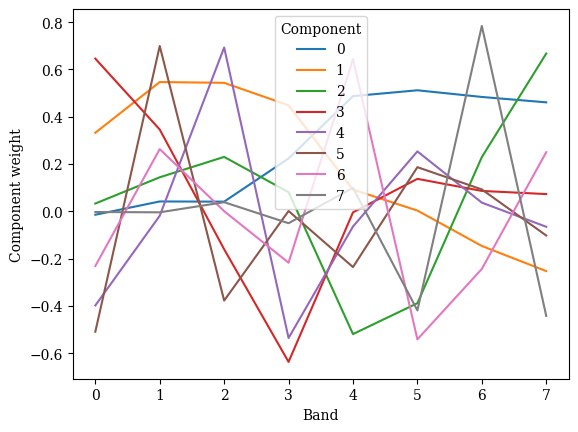

In [7]:
#plot the components

plt.plot(comps[:min(sim_pix.shape[1], 10), :].T, label = range(min(sim_pix.shape[1], 10)))
plt.legend(title = "Component")
plt.xlabel("Band")
plt.ylabel("Component weight")
plt.show()

# Perform presence Absence classification

In [8]:
# divide the dataset into training and testing
x_train, x_test, y_train, y_test = train_test_split(decomposed_mixpix, pixel_fpcs, train_size = 0.5, random_state = 7)
x_train = pd.DataFrame(x_train, index= y_train.index)
x_test = pd.DataFrame(x_test, index = y_test.index)

In [9]:
rf = RandomForestRegressor(
    bootstrap = True,
    ccp_alpha= 0.0,
    criterion = 'absolute_error',
    n_jobs = -1,
    oob_score = True,
    random_state = 123,
    verbose = 1,
    warm_start = False,
    max_features = "sqrt",
    )

In [10]:
classifier_params = {
    "n_estimators": 200,
    "max_depth": 25,
    "min_samples_split": 7,
    "min_samples_leaf": 2,
}

In [11]:
pipe = rfcc.Unmix_Pixels(x_train, y_train, x_test, y_test, presence_absence_thresh= 0.2)
presence_probas = pipe.classify_and_append(classifier_params, plot = "none")

Skipping water regressor plot...
Classification test score: 0.7304
Not plotting kelp classifier...
Classification test score: 0.7324
Not plotting brown_algae classifier...
Classification test score: 0.7518
Not plotting red_veg classifier...
Classification test score: 0.7728
Not plotting green_veg classifier...
Classification test score: 0.8086
Not plotting mineral classifier...


In [12]:
# Store classifications and water reg results
train_classifications = pd.DataFrame({k : v for k, v in presence_probas["train"].items()})
test_classifications = pd.DataFrame({k : v for k, v in presence_probas["test"].items()})


C:\Users\s4770224\AppData\Local\Temp\ipykernel_21056\1794593562.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[col//2, col%2].scatter(x_array[col_name], y_array[:,col], alpha = alpha, c = class_colour, cmap = cmap)


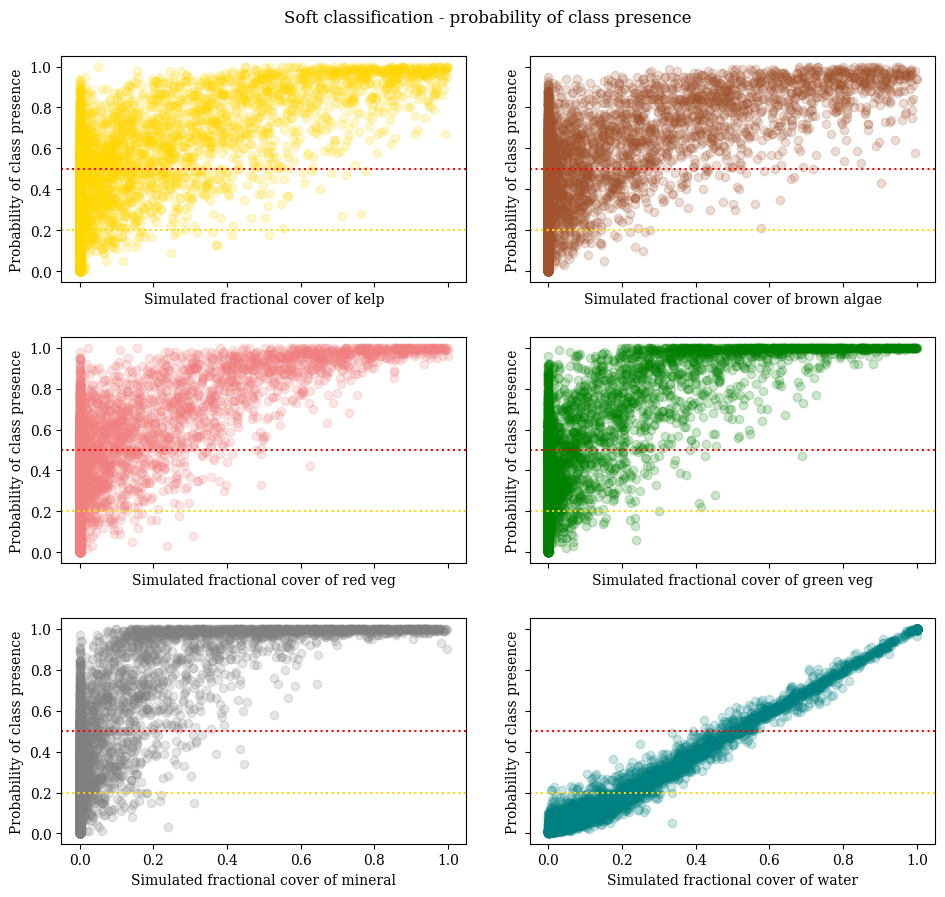

In [13]:
# Plot soft classification results
plotting_params = {
    "x_array": y_test, 
    "y_array": test_classifications, 
    "alpha": 0.2, # p[:,-1],
    "metric" : "MAE", 
    "colour": colours, #p[:,-1],
    "cmap" : "viridis", 
    "fig_title" : "Soft classification - probability of class presence",
    "x_axis_label": "Simulated fractional cover",
    "y_axis_label" : "Probability of class presence", 
    "stats_values" : None,
    "line_1_1" : False, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "h_lines" : [(0.2, "gold"), (0.5, "red")],
    "save" : True,
    "output_dir" : plot_output_dir,
    "output_name" : "soft_classification_testset"
}

plot_multi_result(**plotting_params)  

In [14]:
pd.concat([test_classifications, y_test], axis = 1, names = ["predicted", "true"]).to_csv("testset_soft_classifications.csv", index = True)

# Filter and regress

In [15]:
# Change regressor hyperparams if desired
regressor_params = {
    'bootstrap': True,
    'ccp_alpha': 0.0,
    'criterion': 'absolute_error',
    'max_depth': 10,
    'max_features': 'sqrt',
    'max_leaf_nodes': None,
    'max_samples': 0.6,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 5,
    'min_samples_split': 15,
    'min_weight_fraction_leaf': 0.0,
    'monotonic_cst': None,
    'n_estimators': 100,
    'n_jobs': -1,
    'oob_score': True,
    'random_state': 123,
    'verbose': 0,
    'warm_start': False,  
}

In [83]:
regressor_predictions = pipe.filter_and_regress(plot = "none", regressor_params= regressor_params)

# Store regression results
train_regressions = pd.DataFrame({k : v.iloc[:, 0] for k, v in regressor_predictions["train"].items()})
test_regressions = pd.DataFrame({k : v.iloc[:, 0] for k, v in regressor_predictions["test"].items()})

kelp present in 4117 out of 5000 test pixels
Training set for kelp has 5000 samples
Not plotting kelp regression...
brown_algae present in 4144 out of 5000 test pixels
Training set for brown_algae has 5000 samples
Not plotting brown_algae regression...
red_veg present in 4114 out of 5000 test pixels
Training set for red_veg has 5000 samples
Not plotting red_veg regression...
green_veg present in 3901 out of 5000 test pixels
Training set for green_veg has 5000 samples
Not plotting green_veg regression...
mineral present in 3615 out of 5000 test pixels
Training set for mineral has 5000 samples
Not plotting mineral regression...


In [84]:
# Combine classification and regression results by soft threshold
train_results = combine_class_regression(train_classifications, 
                                         train_regressions, 
                                         0.2)
test_results = combine_class_regression(test_classifications, 
                                        test_regressions, 
                                        0.2)


# Adjust for unity
train_adjusted = train_results.div(train_results.sum(axis = 1), axis = 0)
test_adjusted = test_results.div(test_results.sum(axis = 1), axis = 0)

train_results.replace(np.nan, 0, inplace = True)
test_results.replace(np.nan, 0, inplace = True)
test_adjusted.replace(np.nan, 0, inplace = True)

# Calculate evaluation stats
train_stats = calc_eval_stats(y_train, train_results, include_zeros= False)
test_stats = calc_eval_stats(y_test, test_results, include_zeros = False)
test_adjusted_stats = calc_eval_stats(y_test, test_adjusted, include_zeros = False)

C:\Users\s4770224\AppData\Local\Temp\ipykernel_21056\2328066704.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_results.replace(np.nan, 0, inplace = True)
C:\Users\s4770224\AppData\Local\Temp\ipykernel_21056\2328066704.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_results.replace(np.nan, 0, inplace = True)
C:\Users\s4770224\AppData\Local\Temp\ipykernel_21056\2328066704.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, ex

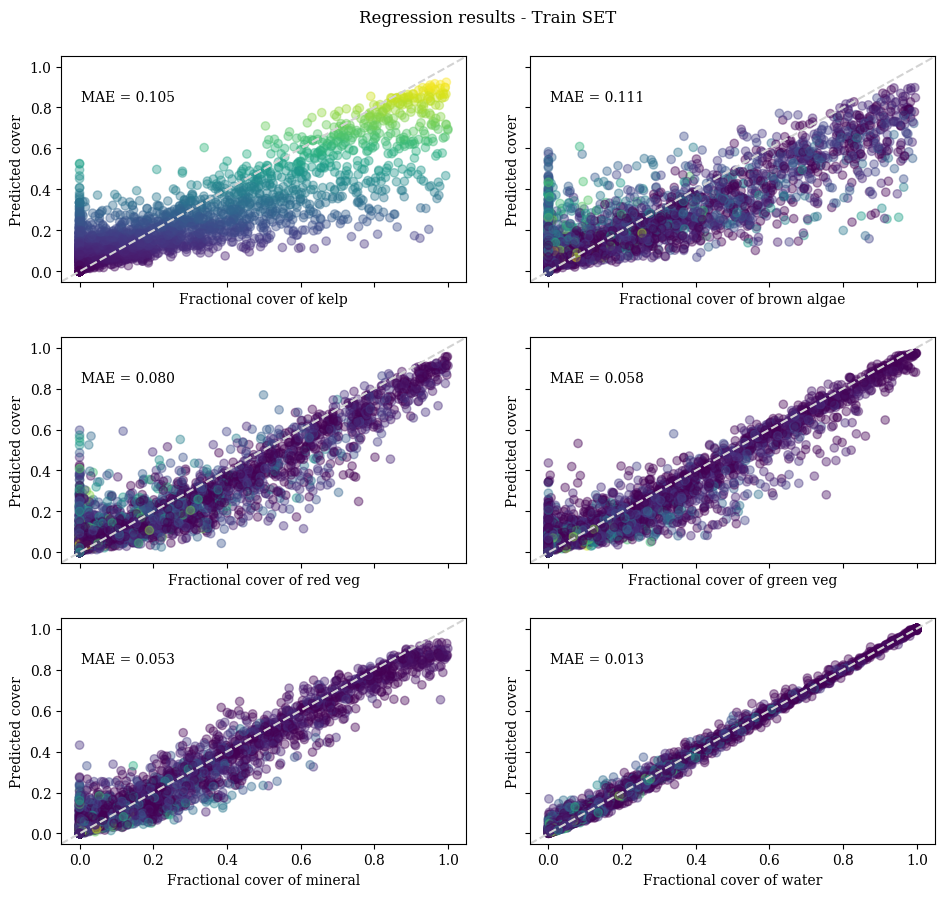

In [85]:
# Plot training regressor results

plotting_params = {
    "x_array": y_train, 
    "y_array": train_results, 
    "alpha": 0.4, # p[:,-1],
    "metric" : "MAE", 
    "colour":train_results.iloc[:, 0], #p[:,-1],
    "cmap" : "viridis", 
    "fig_title" : "Regression results - Train SET",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : train_stats,
    "line_1_1" : True, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "save" : True,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": "reg_test_water_fpc"
}

plot_multi_result(**plotting_params)  

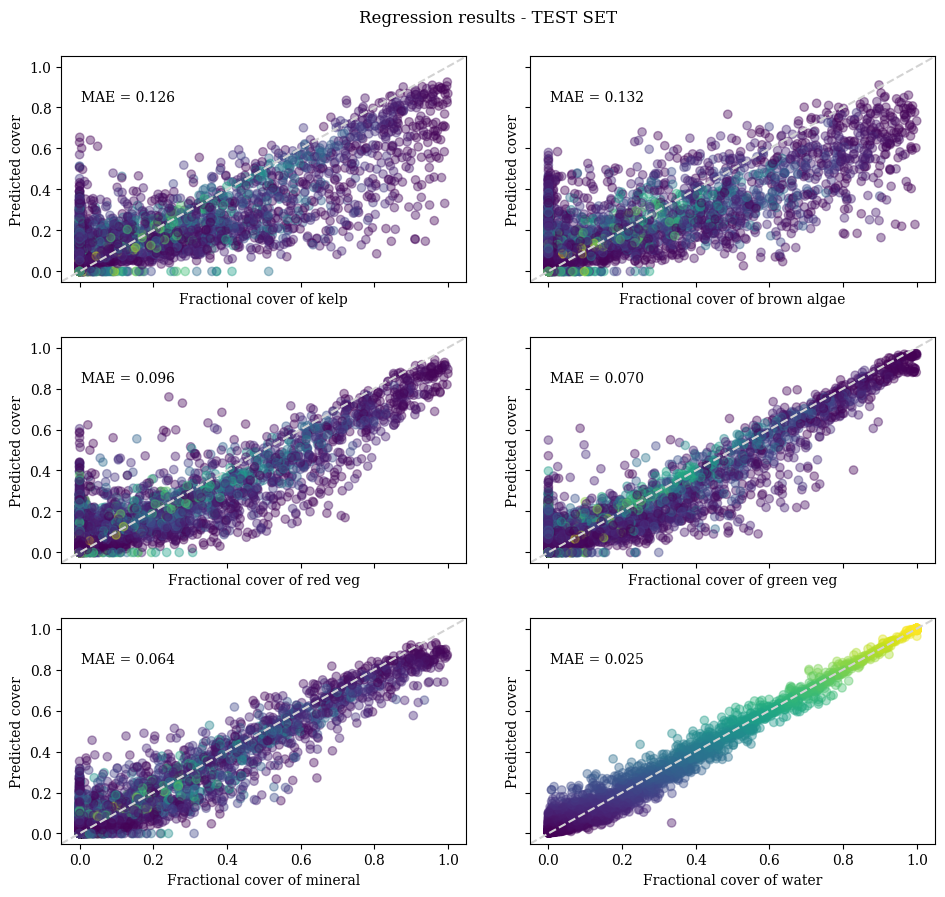

In [86]:
# Plot testing regressor and classifier results

plotting_params = {
    "x_array": y_test, 
    "y_array": test_results, 
    "alpha": 0.4, # p[:,-1],
    "metric" : "MAE", 
    "colour":test_results.iloc[:, -1], #p[:,-1],
    "cmap" : "viridis", 
    "fig_title" : "Regression results - TEST SET",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : test_stats,
    "line_1_1" : True, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "save" : True,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": "reg_test_water_fpc"
}

plot_multi_result(**plotting_params)  

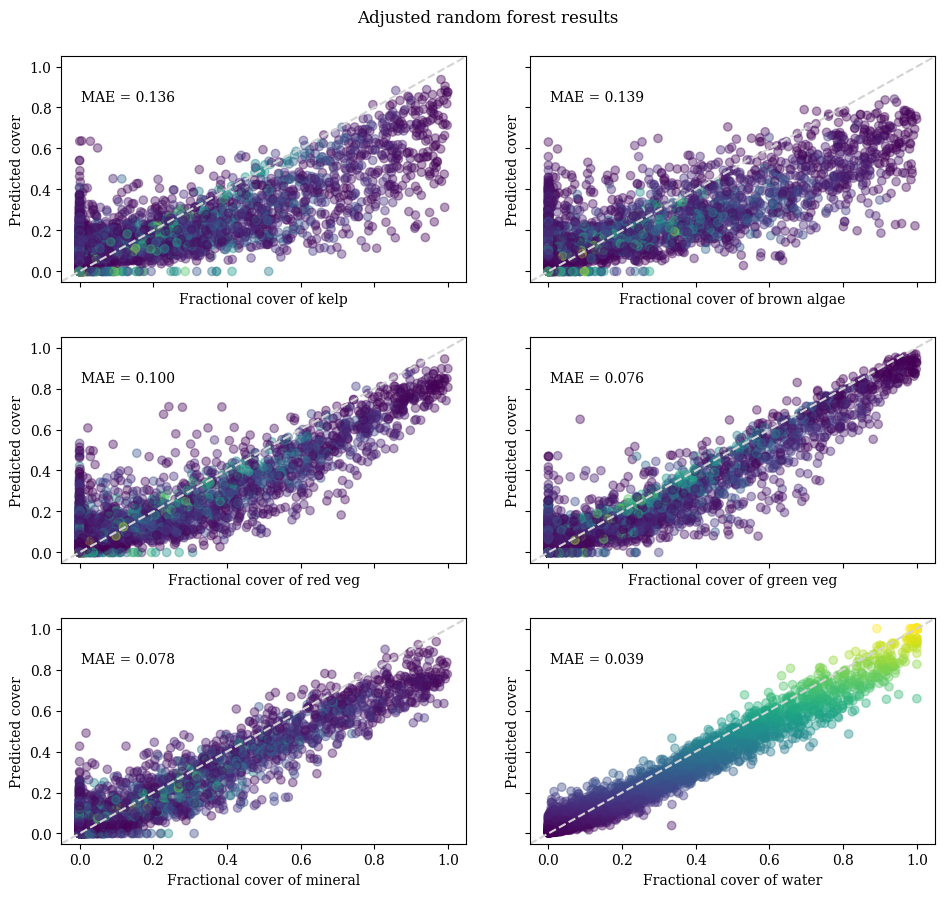

In [87]:
# Plot adjusted regressor results

plotting_params = {
    "x_array": y_test, 
    "y_array": test_adjusted, 
    "alpha": 0.4, # p[:,-1],
    "metric" : "MAE", 
    "colour":test_adjusted.iloc[:, -1], #p[:,-1],
    "cmap" : "viridis", 
    "fig_title" : "Adjusted random forest results",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : test_adjusted_stats,
    "line_1_1" : True, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "save" : True,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": "reg_test_adjusted_water_fpc"
}

plot_multi_result(**plotting_params)  

In [88]:
# Inspect false positive distributions
true_zeros = pd.DataFrame(columns = ["class", "predicted_FPC", "other_brown"])
for col in y_test.columns:
    zeros = y_test[y_test[col] == 0]
    brown = zeros.iloc[:, :-2].sum(axis = 1)
    class_fpc = test_adjusted.loc[zeros.index, col]
    class_name = pd.Series([col for x in brown], index = class_fpc.index)
    class_zeros = pd.concat([class_name, class_fpc, brown], axis =1).rename(columns = {0: "class", col: "predicted_FPC", 1: "other_brown"})
    true_zeros = pd.concat([true_zeros, class_zeros], axis = 0)

C:\Users\s4770224\AppData\Local\Temp\ipykernel_21056\4283908615.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  true_zeros = pd.concat([true_zeros, class_zeros], axis = 0)
C:\Users\s4770224\AppData\Local\Temp\ipykernel_21056\4283908615.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  true_zeros = pd.concat([true_zeros, class_zeros], axis = 0)


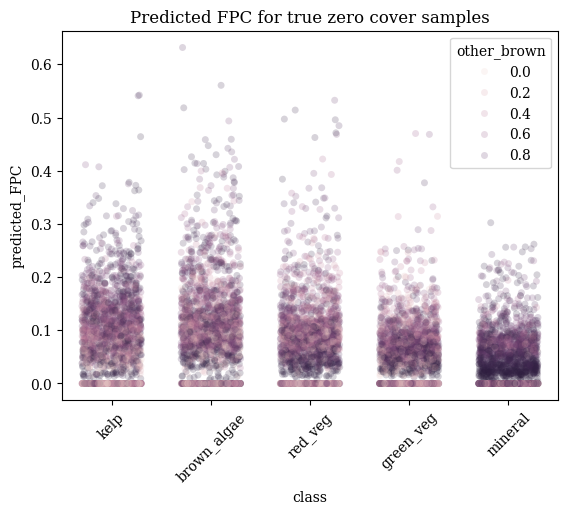

In [89]:
if class_code == "bo_genus":
    true_zeros["numeric_class"] = true_zeros["class"].factorize()[0]
    jittered_x = true_zeros["numeric_class"] + np.random.uniform(-0.3, 0.3, size=len(true_zeros))
    plt.figure(figsize=(12, 12))
    sns.scatterplot(
        x=jittered_x,
        y=true_zeros["predicted_FPC"],
        hue=true_zeros["other_brown"],
        palette="cividis",
        alpha=0.5,
    )    
    plt.xticks(ticks = range(min(true_zeros["numeric_class"]), max(true_zeros["numeric_class"])+1), labels = true_zeros["class"].unique(), rotation = 45)

else:
    sns.stripplot(data = true_zeros, x= "class", y = "predicted_FPC", hue = "other_brown", alpha  = 0.2, jitter = 0.3)
    plt.xticks(rotation = 45)
    plt.savefig(f"{plot_output_dir}/{sensor_code}_{class_code}_false_positives.svg")
    plt.title("Predicted FPC for true zero cover samples")



# Fitting curves and inverting

In [90]:
fitted_curves = {}
all_stats = {}
all_curves = {}
criterion = ("R2", "max")
for col in y_test.columns:
    colour = colours.get(col, "magenta")
    best_fit_params, all_curve_params, best_fit_line, curve_stats = fit_best_curve(y_test.loc[:, col], 
        test_results.loc[:, col],
        criterion = criterion, 
        include_zeros = False)
    print(f"Best fit curve is a {best_fit_line.capitalize()} for {col.replace("_", " ")} with parameters {best_fit_params}")
    fitted_curves[col] = best_fit_params
    all_stats[col] = curve_stats
    all_curves[col] =  all_curve_params

Best fit curve is a Sigmoid for kelp with parameters [ 2.88842597  1.45746063  1.82337132 -0.10040475]
Best fit curve is a Sigmoid for brown algae with parameters [ 2.14133077  1.17001664  1.4317883  -0.23886424]
Best fit curve is a Sigmoid for red veg with parameters [ 2.68536931  1.22348529  2.03998073 -0.12567613]
Best fit curve is a Sigmoid for green veg with parameters [ 1.46070324  0.71739772  3.15732136 -0.08156442]
Best fit curve is a Sigmoid for mineral with parameters [ 1.32344226  0.52590971  3.03695284 -0.18329561]
Best fit curve is a Sigmoid for water with parameters [ 1.96123832  0.57448229  2.18935362 -0.4138596 ]


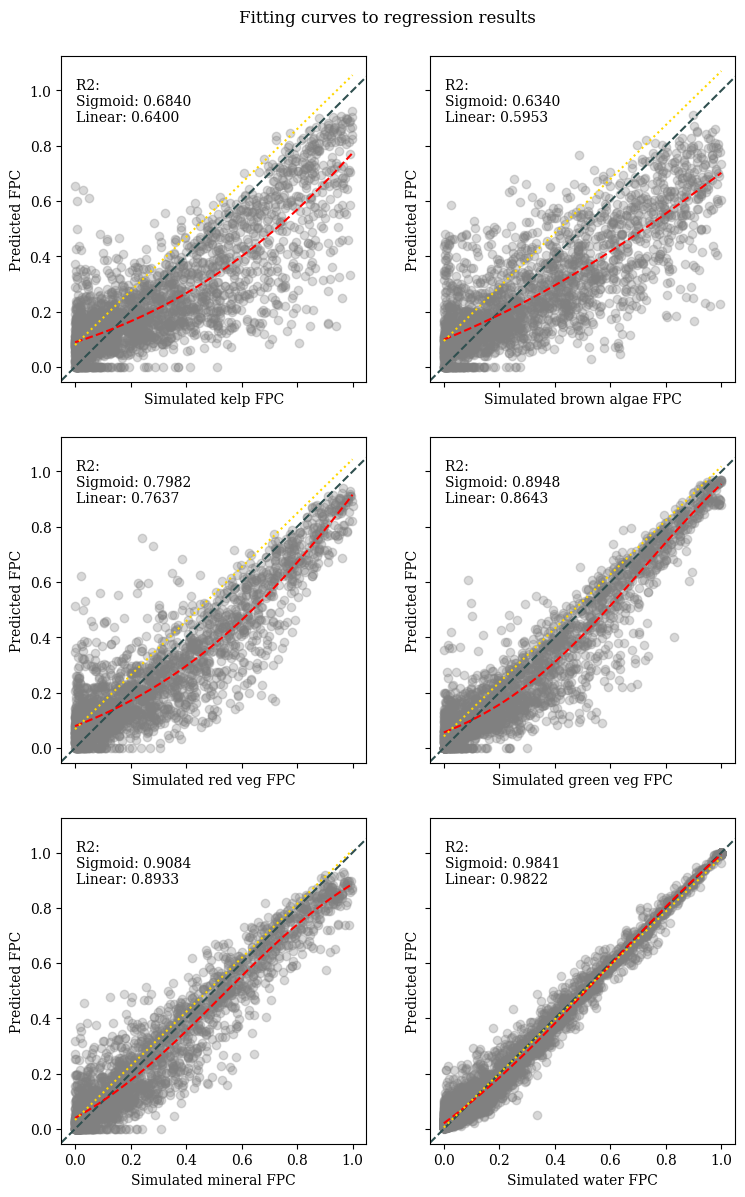

In [91]:
# Plot fitted curves and regression results

fig, ax = plt.subplots(y_test.shape[1]//2 + y_test.shape[1]%2, 2, figsize = (8,12), sharex = True, sharey = True) 
fig.tight_layout(pad = 3)

for col in range(y_test.shape[1]):
    x = y_test[y_test.iloc[:, col] > 0 ]
    y = np.array(test_results[y_test.iloc[:,col] >0])
    col_name = x.columns[col]
    
    class_curves = all_curves.get(col_name)
    class_stats = all_stats.get(col_name)
    x_linspace = np.linspace(np.min(x), np.max(x), 500)
    y_linspace = {
    "sigmoid": sigmoid(x_linspace, *class_curves.get("sigmoid")),
    "linear" : all_curve_params["linear"][0]*x_linspace + class_curves["linear"][1]
    }
    
    ax[col//2, col%2].scatter(x[col_name], y[:,col], alpha = 0.3, c = "grey") #colours[col_name])
    ax[col//2, col%2].set_xlabel(f"Simulated {col_name.replace("_", " ")} FPC")
    ax[col//2, col%2].set_ylabel ("Predicted FPC")
    ax[col//2, col%2].axline((0,0), slope = 1, color = "darkslategrey", alpha = 1, linestyle = "--")
    ax[col//2, col%2].plot(x_linspace, y_linspace["sigmoid"], '--', color = "red", label='Fitted curve - Sigmoid')
    ax[col//2, col%2].plot(x_linspace, y_linspace["linear"], ':', color = "gold", label='Fitted curve - Linear')

    ax[col//2, col%2].annotate(f"{criterion[0].upper()}: \nSigmoid: {class_stats["sigmoid"][criterion[0]][0]:.4f} \nLinear: {class_stats["linear"][criterion[0]][0]:.4f}", xy = (0.05, 0.8), xycoords = "axes fraction", fontsize = 10,)
    
    if x.shape[1] % 2 == 1:
        ax[-1, -1].set_visible(False)  
    fig.suptitle("Fitting curves to regression results", y = 1)

plt.savefig(f"{plot_output_dir}_{sensor_code}_{class_code}_fitting_curves.svg")    
plt.show()

    

In [92]:
# Invert and adjust for totality
inverted_predicted = invert_predicted_values(np.array(test_results), y_test, fitted_curves)
inverted_predicted["water"] = test_adjusted["water"]
adjusted_inverted = inverted_predicted.div(inverted_predicted.sum(axis = 1), axis = 0)
inv_adj_stats = calc_eval_stats(y_test, adjusted_inverted)

In [93]:
# Calculate the extra bloat and deficit caused by false classifications

negs = y_test == 0
posi = y_test >0
positives = test_classifications >= 0.2
negatives = test_classifications< 0.2
false_posi = negs * positives
false_negs = posi * negatives
false_posi_bloat = test_results*false_posi
false_negs_deficit = test_regressions * false_negs

false_posi_bloat.sum()/y_test.sum()

kelp           0.271292
brown_algae    0.307344
red_veg        0.269167
green_veg      0.179697
mineral        0.132046
water          0.000000
dtype: float64

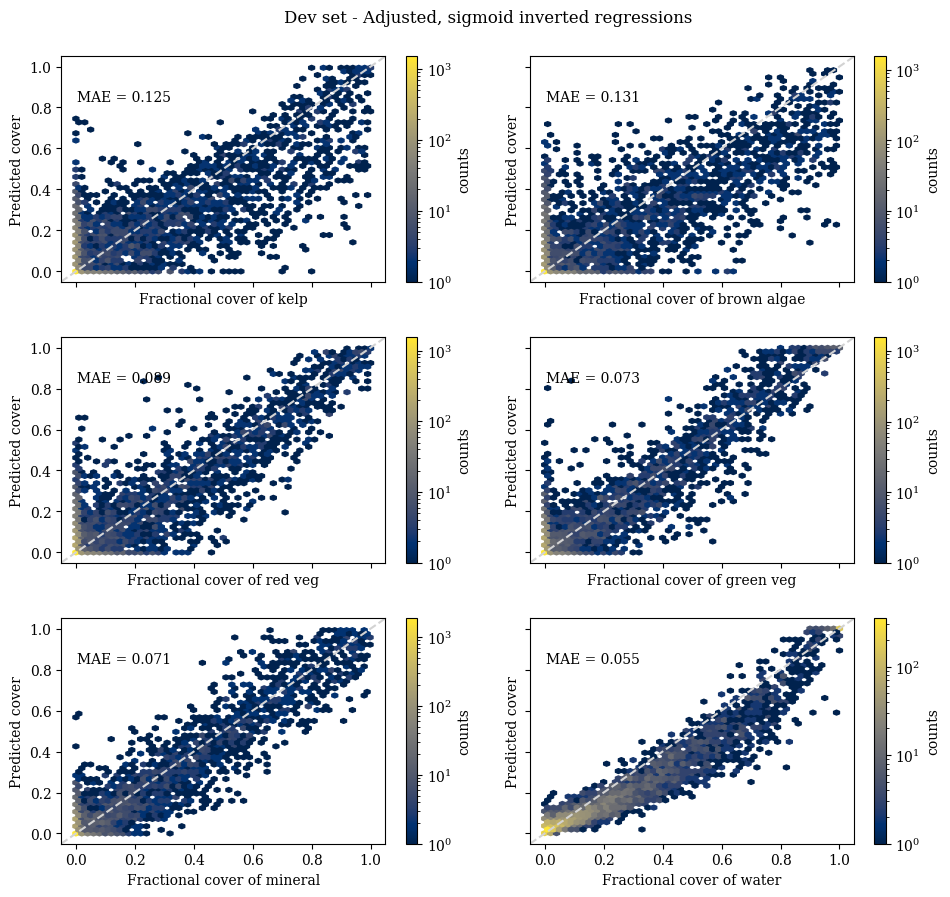

In [94]:
plotting_params = {
    "x_array": y_test, 
    "y_array": adjusted_inverted, 
    "alpha": 0.3, #y_test.iloc[:,-1],
    "colour": y_test.iloc[:,-1],
    "metric" : "MAE",
    "cmap" : "cividis", 
    "fig_title" : f"Dev set - Adjusted, {best_fit_line} inverted regressions",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : inv_adj_stats, 
    "line_1_1" : True,
    "type": "hexbin",
    "sensor_code" : sensor_code,
    "class_code" : class_code, 
    "save" : True,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": f"dev_{best_fit_line}_inv_adj_hexbin"
}
plot_multi_result(**plotting_params)

In [95]:
# # Plot class-wise adjusted results coloured by remaining fraction of total browns
# total_browns = y_test.iloc[:, :-2].sum(axis = 1)
# adjusted_inverted["browns"] = adjusted_inverted.iloc[:, :-2].sum(axis = 1)
# test_adjusted["browns"] = test_adjusted.iloc[:, :-2].sum(axis = 1)


# for col in test_adjusted.columns[:2]:
#     plt.scatter(x = y_test[col],
#                 y = test_adjusted[col], 
#                 marker = '.', 
#                 alpha = 0.5, 
#                 c = total_browns - y_test[col])
#     plt.title(col)
#     plt.xlabel(f"True simulated {col} FPC")
#     plt.ylabel(f"Area - Adjusted predicted FPC for {col}")
#     plt.show()


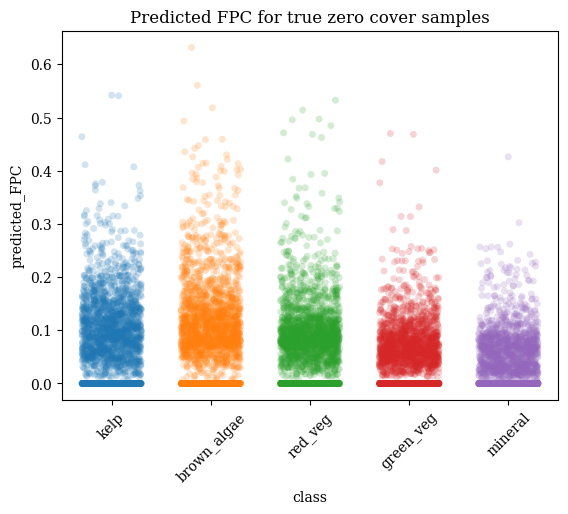

In [96]:
sns.stripplot(data  = true_zeros, x= "class", y = "predicted_FPC", hue = "class", alpha  = 0.2, jitter = 0.3,)
plt.title("Predicted FPC for true zero cover samples")
plt.xticks(rotation = 45)
plt.show() 

# Run Chained classification-regression on new data

In [97]:
# Mix dev and validation  sets 
new_sim_pix = np.load(sim_pix_directory + "unseen_pixels.npy")
new_pixel_fpcs = pd.DataFrame(np.load(sim_pix_directory + "unseen_pixel_fpcs.npy"))
new_endmember_indices = np.load(sim_pix_directory + "unseen_pixel_endmembers.npy")
new_pixel_fpcs.columns = np.load(sim_pix_directory + "development_pixels_columns.npy", allow_pickle = True)

In [98]:
## Improper workflow for testing sensitivity
# # genus_test_columns = ['ecklonia', 'macrocystis', 'undaria', 'acrocarpia', 
#        'carpophyllum', 'cystophora', 'durvillaea', 'hormosira', 'petalonia', 'phyllospora', 'sargassum', 'scytosiphon', 'mineral', 'water']
# temp_fpcs = pd.DataFrame(0, index = new_pixel_fpcs.index, columns = genus_test_columns)
# temp_fpcs.update(new_pixel_fpcs)
# new_pixel_fpcs = temp_fpcs

In [99]:
# Follow proper workflow With dev and validation pixels matching

new_sim_pix = np.load(sim_pix_directory + "unseen_pixels.npy")
new_pixel_fpcs = pd.DataFrame(np.load(sim_pix_directory + "unseen_pixel_fpcs.npy"))
new_endmember_indices = np.load(sim_pix_directory + "unseen_pixel_endmembers.npy")
new_pixel_fpcs.columns = columns

In [100]:
deco_new_sim_pix = pd.DataFrame(deco.transform(new_sim_pix))

In [101]:
# Unmix using the classifier and regressor pipeline
new_pixel_classifications, new_pixel_regressions = pipe.unmix_new_data(deco_new_sim_pix, columns)

In [102]:
# Format the output results
new_pixel_classifications = pd.DataFrame({k : v.iloc[:,0] for k, v in new_pixel_classifications.items()})
new_pixel_regressions = pd.DataFrame({k : v.iloc[:, 0] for k, v in new_pixel_regressions.items()})

In [103]:
# Make any pixel not classified as present have zero cover
new_test_results = combine_class_regression(new_pixel_classifications, new_pixel_regressions, 0.2)

In [104]:
# Calculate evaluation stats
new_stats = calc_eval_stats(new_pixel_fpcs, new_test_results, include_zeros= True)
pd.DataFrame(new_stats)

,R2,MSE,RMSE,MAE,MAPE
0,0.602560,0.026064,0.161444,0.113348,733.493749
1,0.591683,0.027684,0.166385,0.125149,2060.214564
2,0.540321,0.027335,0.165334,0.118673,2745.296670
3,0.853544,0.009520,0.097571,0.067592,1166.154051
4,0.794185,0.013191,0.114852,0.073862,1774.933410
5,0.964376,0.002709,0.052046,0.034171,904.173672


In [105]:
new_adj_results = new_test_results.div(new_test_results.sum(axis = 1), axis = 0)
new_adj_stats = calc_eval_stats(new_pixel_fpcs, new_adj_results, include_zeros = True)

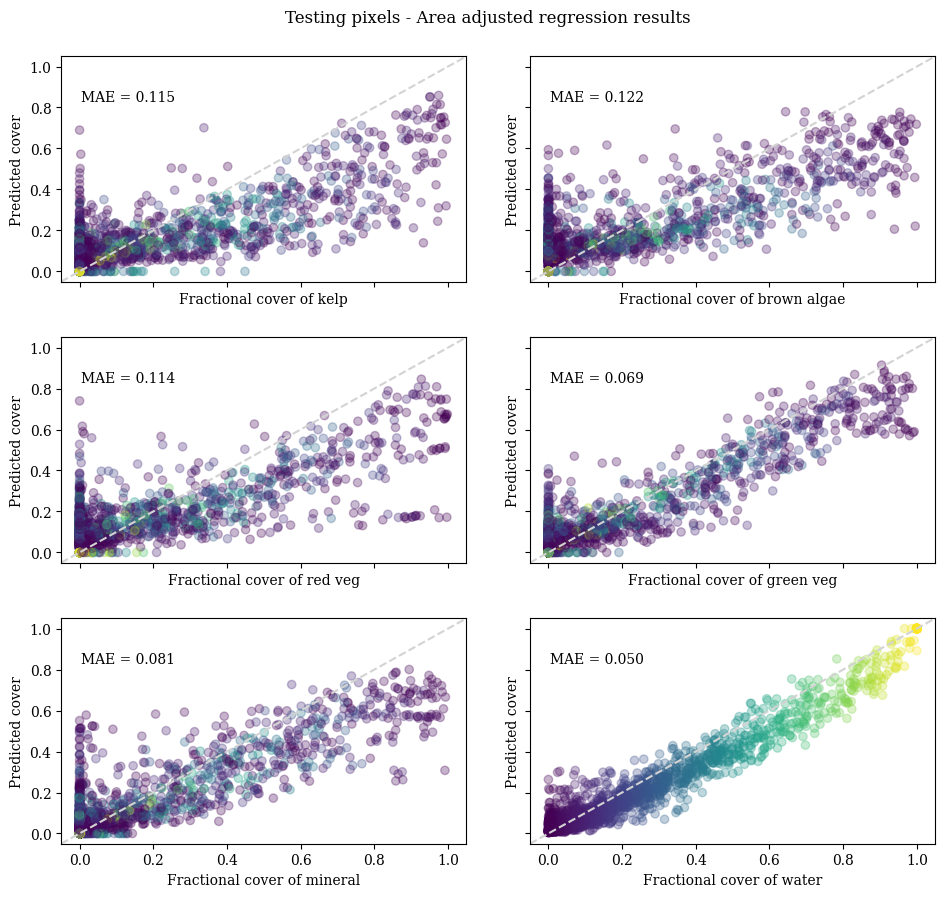

In [106]:
# Plot new data regression results
col = -1
plotting_params = {
    "x_array": new_pixel_fpcs, 
    "y_array": new_adj_results, 
    "alpha": 0.3, #(1-new_pixel_fpcs.iloc[:,-1]), #0.7, #new_overall_test_results.iloc[:,-1], 
    "colour": new_pixel_fpcs.iloc[:,col], #new_endmember_indices[:, 4], #
    "metric" : "MAE",
    "cmap" : "viridis", 
    "fig_title" : f"Testing pixels - Area adjusted regression results",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : new_adj_stats,
    "line_1_1" : True,
    "sensor_code" : sensor_code,
    "class_code" : class_code, 
    "save" : False,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": f"reg_new_data_{new_pixel_fpcs.columns[col]}_fpc", 
    "figsize" : 3
}
plot_multi_result(**plotting_params)  

In [107]:
# Invert and adjust for totality
new_test_inverted = invert_predicted_values(np.array(new_test_results), new_pixel_fpcs, fitted_curves)
new_test_inverted["water"] = new_test_results["water"]
new_inverted_adjusted = new_test_inverted.div(new_test_inverted.sum(axis = 1), axis = 0)
new_inv_adj_stats = calc_eval_stats(new_pixel_fpcs, new_inverted_adjusted)

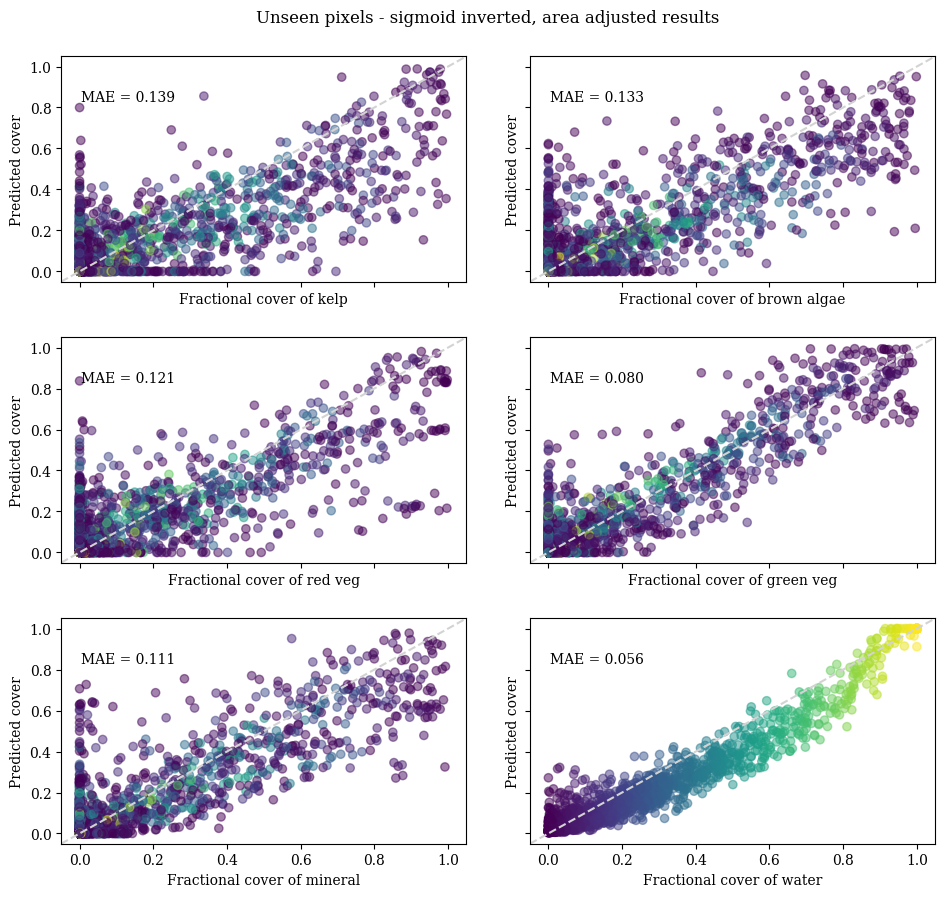

In [108]:
# Plot  results coloured by class FPC
col = -1
plotting_params = {
    "x_array": new_pixel_fpcs, 
    "y_array": new_inverted_adjusted, 
    "alpha": 0.5, #new_p[:,-1],
    "colour": new_pixel_fpcs.iloc[:, col], 
    "metric": "MAE",
    "cmap" : "viridis", 
    "fig_title" : f"Unseen pixels - {best_fit_line} inverted, area adjusted results",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : new_inv_adj_stats,
    "line_1_1" : True, 
    "sensor_code" : sensor_code,
    "class_code" : class_code, 
    "save" : False,
    "figsize" : 3, 
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": f"inv_adj_unseen_{new_pixel_fpcs.columns[col]}_fpc"
}
plot_multi_result(**plotting_params)  

In [109]:
all_eval_stats = pd.concat([pd.DataFrame(train_stats),
                            pd.DataFrame(test_stats),
                            pd.DataFrame(test_adjusted_stats),
                            pd.DataFrame(inv_adj_stats),
                            pd.DataFrame(new_stats),
                            pd.DataFrame(new_adj_stats),
                            pd.DataFrame(new_inv_adj_stats),], axis = 0, ignore_index= True, names=[
                                "Dev Train",
                                "Dev Test",
                                "Dev Test Area Adjusted",
                                "Dev Test Adjusted, Inverted",
                                "Unseen",
                                "Unseen Adjusted",
                                "Unseen Adjusted, Inverted",
                            ])

all_eval_stats.to_csv(f"{sensor_code}_{class_code}_{best_fit_line}_all_eval_statistics.csv", index = True)

print(f"Inverted and Area adjusted: \n {pd.DataFrame(new_inv_adj_stats)}\n \n")
# print(f"Regression predictions : \n {pd.DataFrame(new_stats)} \n \n ")
print(f"Area adjusted regression predictions : \n {pd.DataFrame(new_adj_stats)}")

Inverted and Area adjusted: 
          R2       MSE      RMSE       MAE         MAPE
0  0.528658  0.037748  0.194288  0.139252   500.418620
1  0.620768  0.031957  0.178765  0.132740  1206.228513
2  0.609562  0.031128  0.176431  0.120900   693.223147
3  0.849799  0.012582  0.112170  0.080349   697.863513
4  0.692092  0.025369  0.159278  0.111020  1778.624188
5  0.918387  0.006206  0.078776  0.055614   838.226229
 

Area adjusted regression predictions : 
          R2       MSE      RMSE       MAE         MAPE
0  0.579840  0.027554  0.165994  0.115482   752.978329
1  0.611900  0.026313  0.162214  0.121692  1976.090751
2  0.570903  0.025517  0.159739  0.114057  2762.643330
3  0.851183  0.009674  0.098354  0.069293  1033.683257
4  0.742909  0.016477  0.128365  0.081103  1638.427783
5  0.935960  0.004869  0.069781  0.049759   901.245912


In [110]:
pipe.x_train

,0,1,2,3,4,5,6,7,100,101,102,103,104,105
3655,0.555451,-0.073383,-0.029511,-0.035911,-0.049165,-0.004435,-0.001644,0.000296,0.009609,True,True,True,True,False
9587,0.067305,-0.155861,-0.010105,0.017414,-0.002803,-0.001545,-0.006492,-0.003131,0.246198,True,True,True,True,False
3226,0.102415,-0.105830,-0.014911,0.125996,0.042257,-0.006567,0.006774,0.003045,0.205046,False,True,True,True,True
1244,0.509447,0.089522,-0.040614,-0.074236,-0.119836,0.019763,-0.026115,-0.001909,0.018263,True,True,True,False,True
2581,-1.240011,-0.063172,-0.060799,-0.040764,0.001916,0.000769,0.001807,0.000274,0.970562,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,0.447560,0.157665,0.011541,-0.139655,-0.072720,0.001349,0.004272,0.003240,0.101407,True,False,False,False,True
4307,-0.453214,-0.040807,-0.018334,-0.039610,-0.030080,0.015860,0.004075,-0.002100,0.569418,False,True,True,False,False
5699,-0.095706,-0.027490,0.030838,-0.047861,-0.040497,0.023566,-0.005539,-0.001176,0.363796,False,True,True,False,False
537,-0.612820,-0.175168,0.138486,0.006168,-0.005407,-0.011857,0.009565,-0.002518,0.336228,True,False,True,False,False


## Check out the endmembers going into each pixel

In [111]:
# spectra = pd.read_csv(spec_lib_path, index_col = 0)
# data_test_indices = np.load(sim_pix_directory + "data_test_indices.npy")
# data_test = spectra.loc[data_test_indices, :]

In [112]:
# # Plot the endmembers of a chosen class
# cleaned = [x for x in pd.DataFrame(new_endmember_indices).iloc[:, 0].unique() if not isnan(x)]

# plt.plot(data_test.loc[cleaned, :].T)
# plt.legend(cleaned)
# plt.xticks(rotation = 45)
# plt.xlabel("Sensor Band")
# plt.ylabel("Reflectance")
# plt.show()

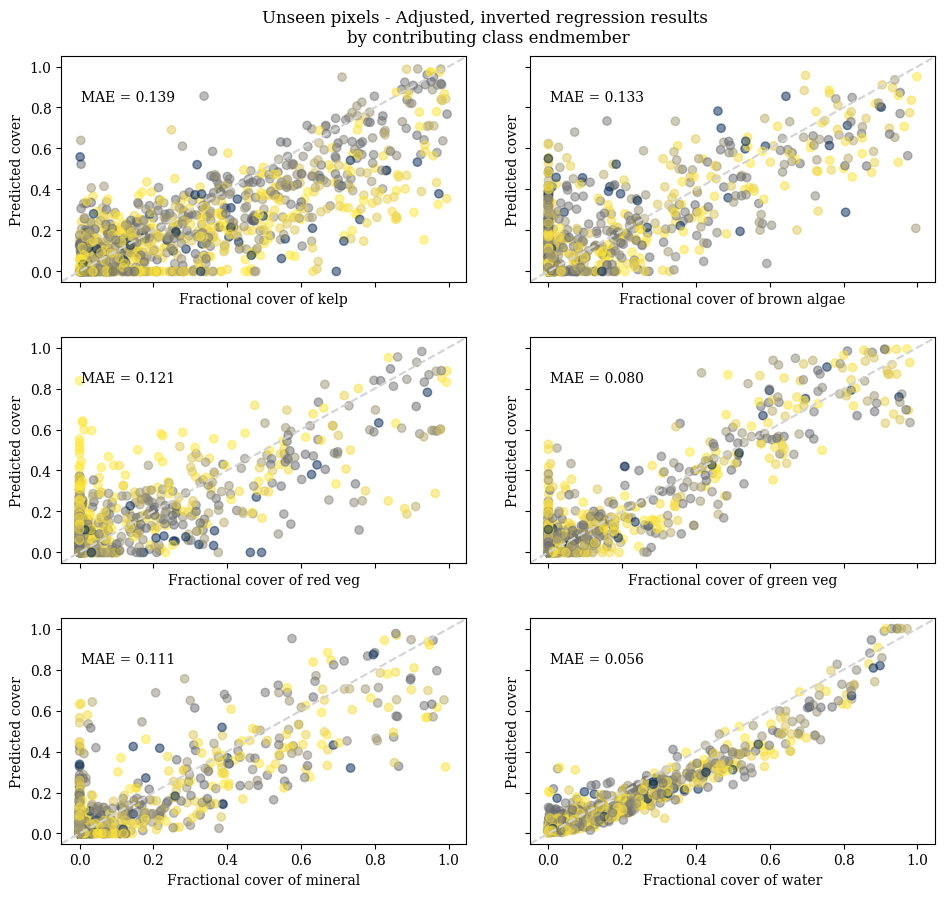

In [113]:
# Plot regression results coloured by class endmember
col = 0
plotting_params = {
    "x_array": new_pixel_fpcs, 
    "y_array": new_inverted_adjusted, 
    "alpha": 0.5, #new_p[:,-1],
    "colour": new_endmember_indices[:, col], # new_p[:,-1],
    "metric": "MAE",
    "cmap" : "cividis", 
    "fig_title" : "Unseen pixels - Adjusted, inverted regression results \nby contributing class endmember",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : new_inv_adj_stats,
    "line_1_1" : True, 
    "sensor_code" : sensor_code,
    "class_code" : class_code, 
    "save" : True,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": f"inv_adj_unseen_{new_pixel_fpcs.columns[col]}_endmembers"
}
plot_multi_result(**plotting_params)  